In [42]:
from xaikd import datasets, models, attributors

import numpy as np

from matplotlib import pyplot as plt 

import numpy as np 

In [2]:
ds = datasets.construct("cifar100-people")

We are building `cifar100-people` containing 5 fine classes
> baby (2)
> boy (11)
> girl (35)
> man (46)
> woman (98)


In [3]:
model = models.get_model("cifar100-resnet18-p1")

In [41]:
arr_act = attributors.extract_activation(
    model, 
    "layer3",
    ds,
    ds.loader(train_split=True)
)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:26<00:00,  1.51it/s]


In [37]:
arr_std = arr_act.std(axis=0)

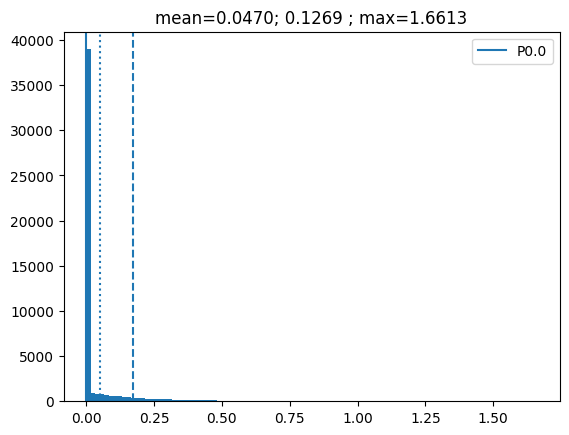

In [50]:
k = 5
pert = 50
plt.hist(arr_act[:, k], bins=100)
plt.title(f"mean={np.mean(arr_act[:, k].mean()):.4f}; {arr_act[:, k].std():.4f} ; max={arr_act[:, k].max():.4f}")
plt.axvline(0.05, ls=':')
percentile = np.percentile(arr_act[:, k], pert) 
plt.axvline(percentile, label=f"P{percentile}")
plt.axvline(arr_std[k], ls="--")
plt.legend()

(array([ 3., 17., 53., 61., 46., 35., 22., 12.,  2.,  5.]),
 array([0.07914314, 0.0933133 , 0.10748345, 0.12165361, 0.13582376,
        0.14999391, 0.16416407, 0.17833422, 0.19250438, 0.20667453,
        0.22084469]),
 <BarContainer object of 10 artists>)

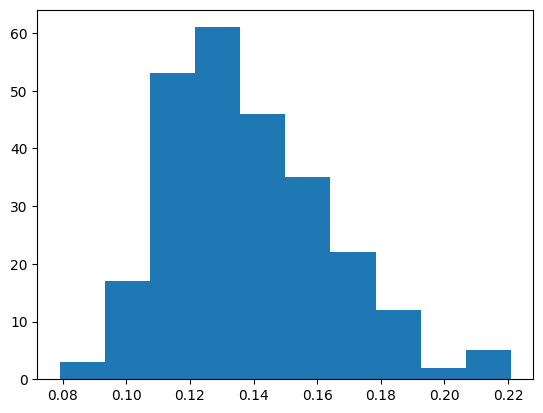

In [63]:
plt.hist(
    np.std(arr_act, axis=0)
)

In [62]:
0.0470 - 0.1*0.1269

0.03431

In [14]:
arr_act.std(axis=0)

array([0.11339684, 0.13107067, 0.12246826, 0.15386106, 0.16568658,
       0.1289    , 0.16371171, 0.10883316, 0.1316226 , 0.11537251,
       0.12134955, 0.11236765, 0.181469  , 0.12505868, 0.13382539,
       0.16894825, 0.17286456, 0.16690512, 0.15914564, 0.14486997,
       0.1364352 , 0.1541666 , 0.11515987, 0.1372501 , 0.11887993,
       0.13098224, 0.14942294, 0.10781427, 0.16604514, 0.10458629,
       0.10878623, 0.18033211, 0.15060891, 0.14139251, 0.17756538,
       0.12897032, 0.1353381 , 0.09454255, 0.17410743, 0.20443748,
       0.16839536, 0.11143775, 0.10141283, 0.11402421, 0.13591473,
       0.11504787, 0.14907056, 0.13541998, 0.16112252, 0.12292193,
       0.13800272, 0.15135986, 0.14318557, 0.10997984, 0.15159042,
       0.16229464, 0.146223  , 0.13197471, 0.16722216, 0.15171959,
       0.2197082 , 0.16874988, 0.13977951, 0.15138799, 0.12186966,
       0.18646772, 0.13527258, 0.12345524, 0.12219507, 0.11890454,
       0.10670067, 0.17235024, 0.12715825, 0.1610347 , 0.14489

In [64]:
ds_cifar100 = datasets.construct("cifar100")

In [67]:
from xaikd.utils import metrics

In [69]:
metrics.accuracy(
    model, 
    ds_cifar100.loader(train_split=False),
    num_classes=100, 
    device="cpu"
)

0.6840000152587891

In [71]:
100 - 24.39

75.61

In [72]:
1 - 0.6840000152587891

0.31599998474121094